In [ ]:
from pathlib import Path
from collections import Counter
import math
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

In [2]:
KAGGLE = os.path.exists('kaggle')

DATA_ROOT = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction") if KAGGLE else Path("../data")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"TEST_DIR  = {TEST_DIR}")

DATA_ROOT = ../data
TRAIN_DIR = ../data/train
TEST_DIR  = ../data/test


In [3]:
train_horizontal_well = list(TRAIN_DIR.glob("*_horizontal_well.csv"))
train_typewell = list(TRAIN_DIR.glob("*_typewell.csv"))
test_horizontal_well = list(TEST_DIR.glob("*_horizontal_well.csv"))
test_typewell = list(TEST_DIR.glob("*_typewell.csv"))

In [4]:
def extract_well_id(well_path: Path) -> int:
    return well_path.stem.split("__")[0]

In [ ]:
def make_wells_df(well_path_list: list[Path]) -> pd.DataFrame:
    wells = []
    for well_path in tqdm(well_path_list, total=len(well_path_list)):
        df = pd.read_csv(well_path)
        id_well = extract_well_id(well_path)
        coords  = df[['X', 'Y', 'Z']].apply(tuple, axis=1)
        wells.append((id_well, coords))
    
    return pd.DataFrame(wells, columns=['id', 'coords'])

train_horizontal_wells_df = make_wells_df(train_horizontal_well)
test_horizontal_wells_df = make_wells_df(test_horizontal_well)



100%|██████████| 3/3 [00:00<00:00, 84.41it/s]

(773, 2)


In [6]:
def plot_wells_path_2D(train_horizontal_wells_df: pd.DataFrame, test_horizontal_wells_df: pd.DataFrame):
    for _, row in train_horizontal_wells_df.iterrows():
        coords = row['coords']
        X, Y, Z = zip(*coords)
        plt.plot(X, Y, label=row['id'], color='c', linewidth=0.5)
    for _, row in test_horizontal_wells_df.iterrows():
        coords = row['coords']
        X, Y, Z = zip(*coords)
        plt.plot(X, Y, label=row['id'], color='r', linewidth=1)
    # plt.legend()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Wells paths in (x, y) plane.")
    plt.show()

# plot_wells_path_2D(train_horizontal_wells_df, test_horizontal_wells_df)

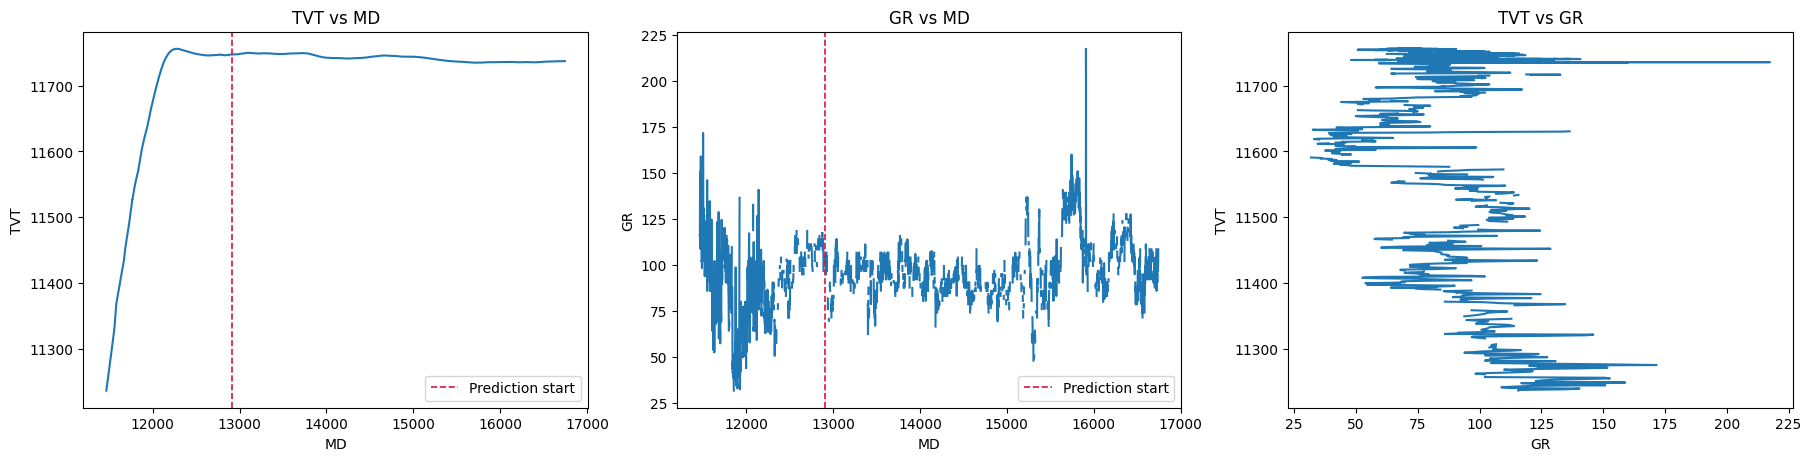

In [18]:
def first_missing_index(series):
    mask = series.isna()
    return int(np.flatnonzero(mask.to_numpy())[0]) if mask.any() else None

def plot_horizontal_well_overview(well_path: Path):
    id_well = extract_well_id(well_path)
    df = pd.read_csv(well_path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

    y = ['TVT', 'GR', 'TVT']
    x = ['MD', 'MD', 'GR']
    for ax, x, y in zip(axes, x, y):
    
        ax.plot(df[x], df[y])
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs {x}")

        if x == 'MD' and 'TVT_input' in df.columns:
            ps_idx = first_missing_index(df['TVT_input'])
            if ps_idx is not None:
                ax.axvline(df.loc[ps_idx, 'MD'], color='crimson', ls='--', lw=1.2, label='Prediction start')
                ax.legend(loc='best')

    plt.show()

well_path = train_horizontal_well[0]

plot_horizontal_well_overview(well_path)

,direction,percent
0,nearly flat,52.128849
1,increasing,32.510479
2,decreasing,15.360673


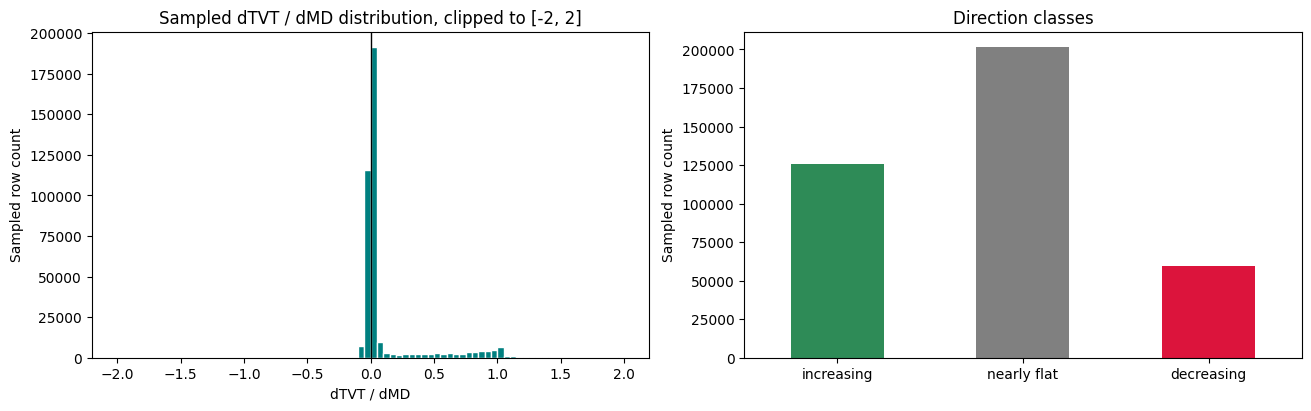

In [21]:
slope_rows = []

for i, path in enumerate(train_horizontal_well):
    df = pd.read_csv(path, usecols=["MD", "TVT"])
    dmd = df["MD"].diff()
    dtvt = df["TVT"].diff()
    slope = (dtvt / dmd).replace([np.inf, -np.inf], np.nan).dropna()

    if len(slope) > 500:
        slope = slope.sample(500, random_state=RANDOM_STATE + i)

    slope_rows.append(pd.DataFrame({"well_id": extract_well_id(path), "dTVT_dMD": slope}))

slope_df = pd.concat(slope_rows, ignore_index=True)
flat_eps = 0.02
slope_df["direction"] = np.select(
    [slope_df["dTVT_dMD"] > flat_eps, slope_df["dTVT_dMD"] < -flat_eps],
    ["increasing", "decreasing"],
    default="nearly flat",
)

display(slope_df["direction"].value_counts(normalize=True).mul(100).rename("percent").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(slope_df["dTVT_dMD"].clip(-2, 2), bins=80, color="teal", edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Sampled dTVT / dMD distribution, clipped to [-2, 2]")
axes[0].set_xlabel("dTVT / dMD")
axes[0].set_ylabel("Sampled row count")

slope_df["direction"].value_counts().reindex(["increasing", "nearly flat", "decreasing"]).plot(
    kind="bar", ax=axes[1], color=["seagreen", "gray", "crimson"]
)
axes[1].set_title("Direction classes")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sampled row count")
axes[1].tick_params(axis="x", rotation=0)
plt.show()